# Aarhus Universitet &mdash; SWMAL E25
## Assignment O4
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | 201809623    |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**04/12-2025**

# Introduction

This report presents our final end-to-end machine learning project for O4. Our goal is to build an image-classification system that predicts the breed of a cat from a photo. We will focus on five breeds, Bengal, Domestric Shorthair, Maine Coon, Ragdoll and Siamese. We want to design and implement a pipeline, so that new breeds can be added with minimal changes.

We use the Kaggle Cats Breed dataset combined with the relevant breeds from Kaggles CatBreedsRefined-7k and the Siamese cat Image Classification Dataset from images.cv, which gives us real world images of five different breeds with variation in resolution, lighting and background.

In the report, we follow an end-to-end structure, which defines the problem, describe the dataset, our choice of machine learning methods, explaining how we process, train, and evaluate our model. We will also discuss performance metrics, risks of under- and overfitting, and the optimizations used to improve generalization. The report concludes with key results and reflections on possible future improvements.

# Problem statement

The goal is to develop a machine learning model that can identify the breed of a cat from an image. Correctly recognizing car breeds is a task that involves understanding visual features such as fur pattern, colors, shape and orhter characteristics. However, these features could possibly be subtle and difficult to distinguish, especially on breeds that look alike.

The main challenge of real-world images, is that they can vary in lighting, resolution, pose and background, which makes it harder for a model to focus on the important features of the cat, instead of background and lighting features. Our approach includes preparing and cleaning the dataset, selecting appropriate machine learning methods, training the model and evaluation its performance using relevant metrics. We want to create a model that can somewhat reliably predict the five target cat breeds and can be expanded to include more breeds in the future.

# Dataset

### a. Concept

We want to build a robust image-classifier that predicts a cat’s breed from a single photo. The initial scope covers five breeds—Bengal, Domestic Shorthair, Maine Coon, Ragdoll, and Siamese, but the architecture will be modular (Each cat breed has their own folder) so adding new classes later requires only dropping more folders into the dataset, re-running the split and re-training or fine-tuning. We normalize inputs consistently, apply conservative augmentations to improve generalization (flip/rotate/brightness/contrast/zoom), and track performance with accuracy and macro-averaged F1. To understand model behavior, we’ll use a confusion matrix and per-class metrics; this is especially useful for visually similar breeds or when classes are imbalanced. The end product is a saved model artifact plus a small script that takes an image path and returns top-1 prediction with confidence, and maybe top-k probabilities for transparency.


### b. Dataset

We use the [Kaggle Cat's Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset) combined with the relevant breeds from [Kaggles CatBreedsRefined-7k](https://www.kaggle.com/datasets/doctrinek/catbreedsrefined-7k) and the [Siamese cat Image Classification Dataset](https://images.cv/dataset/siamese-cat-image-classification-dataset). This provides us with five cat classes which we target and already follows a directory-per-breed structure. This structure is compatible with standard loaders fx. (Keras `image_dataset_from_directory`) and plays nicely with reproducible train/validation/test splits. The pipeline stays open to growth: if we later collect more images for these breeds or introduce new breeds, we simply add folders with the appropriate names and rerun the preprocessing/splitting steps. This makes it straightforward to scale both the data and the classification without rewriting code.

### c. Dataset description

Each sample is a color photograph (commonly JPEG/PNG in RGB) with non-uniform resolution and aspect ratio. Labels are implicitly defined by folder names, which reduces the chance of metadata drift but can still contain occasional label noise (mis-sorted images). In a quick exploration pass, we verify the directory layout, count the images per class, and check for corrupt files or near-duplicates using a perceptual hash. We look at global summaries like width/height distributions and aspect ratios to inform the target input size and resizing policy (e.g., pad/crop vs. stretch). We also visualize single-image RGB histograms and small grids of random examples per class to spot systematic differences such as background bias (studio shots vs. household environments), lighting extremes, or watermark artifacts. To hold the scope of the project down we won't go through the pictures for background bias, as i might take a lot of time. There might be some issuese which could be mild class imbalance, resolution variance, and varied backgrounds that can mislead the model into learning context instead of the cat. 


### d. Use of dataset

We’ll use the dataset for multiclass classification: given a cat photo, predict one breed among our five classes. Classification fits because the target is a discrete label, not a numeric value (so not regression). We’ll resize and convert to RGB to standardize inputs and stabilize training, then make stratified train/validation/test splits to get fair evaluation. For metrics, we pick accuracy for overall performance and macro-F1 so small classes count equally (We might add a cat breed with not a lot of pictures). We will use a confusion matrix that shows us which breeds the model confuses.

### Sources:

- [Kaggle Cat’s Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset)
- [Siamese cat Image Classification Dataset](https://images.cv/dataset/siamese-cat-image-classification-dataset)
- [Kaggles CatBreedsRefined-7k](https://www.kaggle.com/datasets/doctrinek/catbreedsrefined-7k)
- [scikit-learn: train_test_split (stratified splitting)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [scikit-learn: StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [scikit-learn: StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html)
- [scikit-learn: StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [scikit-learn: f1_score (use `average="macro"`) ](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [scikit-learn: confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [scikit-learn: ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [scikit-learn: classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [scikit-learn: cross_validate (multi-metric CV)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
- [scikit-learn User Guide: Metrics & scoring (classification metrics)](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [scikit-learn User Guide: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)


We start by setting the dataset path, importing the libraries, and configuring plotting so the rest of the notebook knows where the images are and can visualize results consistently.

In [89]:
# Setup: Datapath and imports
DATA_DIR = "CatData/cat_v1"

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True


Next, we scan the class folders, open each image, and record format, color mode, width, height, and aspect ratio to build a simple metadata table.

In [90]:
# Scan dataset (formats, color spaces, sizes)
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".tif",".tiff",".webp"}

rows, bad = [], []
root = Path(DATA_DIR)
classes = sorted([d.name for d in root.iterdir() if d.is_dir()])

for cls in classes:
    for p in (root/cls).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            try:
                with Image.open(p) as im:
                    im.load()
                    w, h = im.size
                    rows.append({
                        "path": str(p),
                        "label": cls,
                        "format": im.format,    # JPEG, PNG, ...
                        "mode": im.mode,        # RGB, L, RGBA, ...
                        "width": w,
                        "height": h,
                        "aspect": (w/h if h else np.nan)
                    })
            except (UnidentifiedImageError, OSError):
                bad.append(str(p))

meta = pd.DataFrame(rows)
print(f"Classes: {classes}")
print(f"Total images: {len(meta)}  |  Unreadable: {len(bad)}")
meta.head()


Classes: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
Total images: 3649  |  Unreadable: 0


,path,label,format,mode,width,height,aspect
0,CatData\cat_v1\bengal\00438-Bengal-cat-snarlin...,bengal,JPEG,RGB,1120,1104,1.014493
1,CatData\cat_v1\bengal\00441-Very-timid-Brown-S...,bengal,JPEG,RGB,1414,1104,1.280797
2,CatData\cat_v1\bengal\00e79f939696ea0c09560315...,bengal,JPEG,RGB,2554,3222,0.792675
3,CatData\cat_v1\bengal\03915-Pair-of-Bengal-kit...,bengal,JPEG,RGB,1102,1104,0.998188
4,CatData\cat_v1\bengal\04413-Bengal-cat-white-b...,bengal,JPEG,RGB,1038,1104,0.940217


Then we print a directory tree to document how the data are organized on disk, showing the root and the class subfolders.

In [91]:
# Representation on disk (folder structure)
def print_tree(path: Path, max_depth=1):
    def _walk(p, prefix="", depth=0):
        if depth > max_depth: return
        entries = sorted(p.iterdir(), key=lambda x: (not x.is_dir(), x.name.lower()))
        for i, e in enumerate(entries[:50]):  # truncate for readability
            is_last = (i == len(entries)-1)
            branch = "└── " if is_last else "├── "
            print(prefix + branch + e.name + ("/" if e.is_dir() else ""))
            if e.is_dir():
                _walk(e, prefix + ("    " if is_last else "│   "), depth+1)
    print(p.name + "/")
    _walk(path)

print_tree(root, max_depth=1)


zxtw5kluwri21.jpg/
├── bengal/
│   ├── 00438-Bengal-cat-snarling.jpg
│   ├── 00441-Very-timid-Brown-Spotted-Bengal-cat-ears-back.jpg
│   ├── 00e79f939696ea0c095603154c4af840.jpg
│   ├── 03915-Pair-of-Bengal-kittens-white-background.jpg
│   ├── 04413-Bengal-cat-white-background.jpg
│   ├── 047ffa2f7165ccc4585e418ddb800299.jpg
│   ├── 05050-Brown-spotted-Bengal-cat-sitting-on-grey-background.jpg
│   ├── 09a0c5d574f818471c84cf509fc786dc.jpg
│   ├── 0c87060cea587a01f0a254066c95deaa.jpg
│   ├── 106f59608bc9fc6ac11df31008efdf94.jpg
│   ├── 1096165.jpg
│   ├── 1111246.jpg
│   ├── 1113154.jpg
│   ├── 1142194.jpg
│   ├── 119mokiL1.jpg
│   ├── 1200px-Bangie_the_Bengal_Cat.jpg
│   ├── 122433177_3649288731759742_6202950879910256561_o.jpg
│   ├── 12651963_f520.jpg
│   ├── 14105889_f520.jpg
│   ├── 15658-Brown-spotted-Bengal-female-cat.jpg
│   ├── 15a0a84bd11fcae601ed41f5672191ba.jpg
│   ├── 1aeae43be56c47450ef4a3354d3e940d.jpg
│   ├── 1b2a68f85a32410fb3fd776927a2f4ef.jpg
│   ├── 1e8351aa322b32f7a23

After that, we show class counts and simple tables of image formats and color modes. This checks how balanced the classes are and what kinds of files we have.

In [92]:
# Basic tables
# Class counts
cls_counts = meta["label"].value_counts().sort_index()
display(pd.DataFrame({"count": cls_counts}))

# Formats & color spaces
display(meta["format"].value_counts().to_frame("count").rename_axis("format"))
display(meta["mode"].value_counts().to_frame("count").rename_axis("mode"))


,count
label,
bengal,527
domestic_shorthair,520
maine_coon,540
ragdoll,557
siamese,1505


,count
format,
JPEG,3639
PNG,7
MPO,2
WEBP,1


,count
mode,
RGB,3644
RGBA,2
P,2
L,1


We then compute size stats per class and plot histograms of width, height, and aspect ratio. This tells us how big images are and helps if we want to choose a standard resize.

width                               height              \
                   count  min median        mean   max  count  min median   
label                                                                       
bengal               527  192  500.0  888.573055  6016    527  145  375.0   
domestic_shorthair   520  190  300.0  881.950000  7793    520  148  400.0   
maine_coon           540  116  500.0  841.179630  5616    540  155  500.0   
ragdoll              557  172  500.0  932.976661  6000    557  112  456.0   
siamese             1505  256  256.0  500.795349  6000   1505  256  256.0   

                                     aspect                                \
                          mean   max  count       min    median      mean   
label                                                                       
bengal              743.022770  4928    527  0.496000  1.333333  1.247432   
domestic_shorthair  865.788462  5472    520  0.483871  1.000000  1.042985   
maine_coon          832.737037  6000    540  0.483871  1.000000  1.065800   
ragdoll             861.725314  5389    557  0.476948  1.259214  1.160972   
siamese             469.294352  4630   1505  0.495495  1.000000  1.026400   

                             megapix                                           
                         max   count       min    median      mean        max  
label                                                                          
bengal              2.173913     527  0.031872  0.167000  1.368529  24.064000  
domestic_shorthair  2.027027     520  0.044400  0.120000  1.684241  40.484635  
maine_coon          2.183406     540  0.017980  0.185250  1.324973  25.000000  
ragdoll             2.678571     557  0.028552  0.187500  1.510091  24.000000  
siamese             2.370370    1505  0.065536  0.065536  0.671737  24.000000

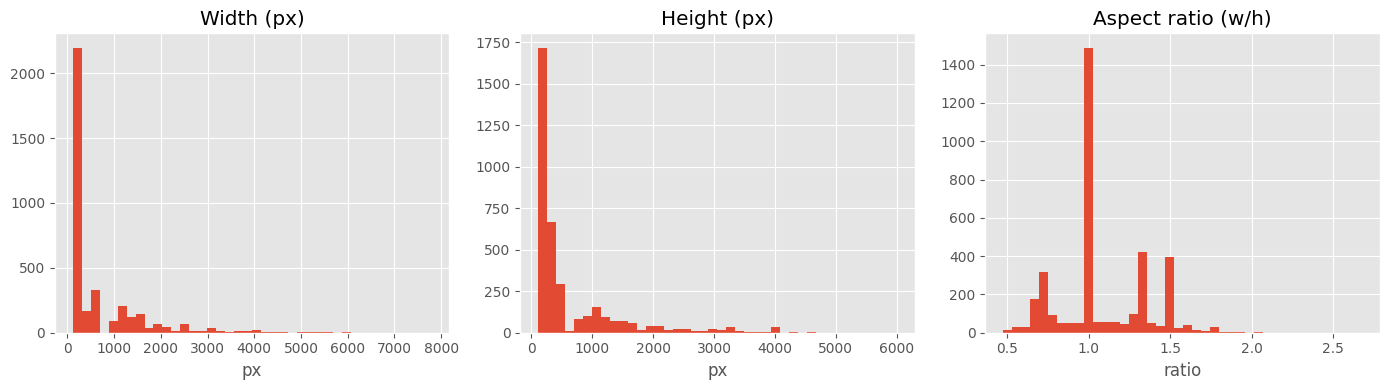

In [93]:
# Size statistics + histograms (width/height/aspect)
size_stats = (meta
    .assign(megapix=(meta["width"]*meta["height"])/1e6)
    .groupby("label")[["width","height","aspect","megapix"]]
    .agg(["count","min","median","mean","max"]))
display(size_stats)

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes[0].hist(meta["width"],  bins=40); axes[0].set_title("Width (px)");  axes[0].set_xlabel("px")
axes[1].hist(meta["height"], bins=40); axes[1].set_title("Height (px)"); axes[1].set_xlabel("px")
axes[2].hist(meta["aspect"], bins=40); axes[2].set_title("Aspect ratio (w/h)"); axes[2].set_xlabel("ratio")
plt.tight_layout(); plt.show()


Next, we show a small grid of example images for each class with their labels. This is a quick visual check that the data look right.

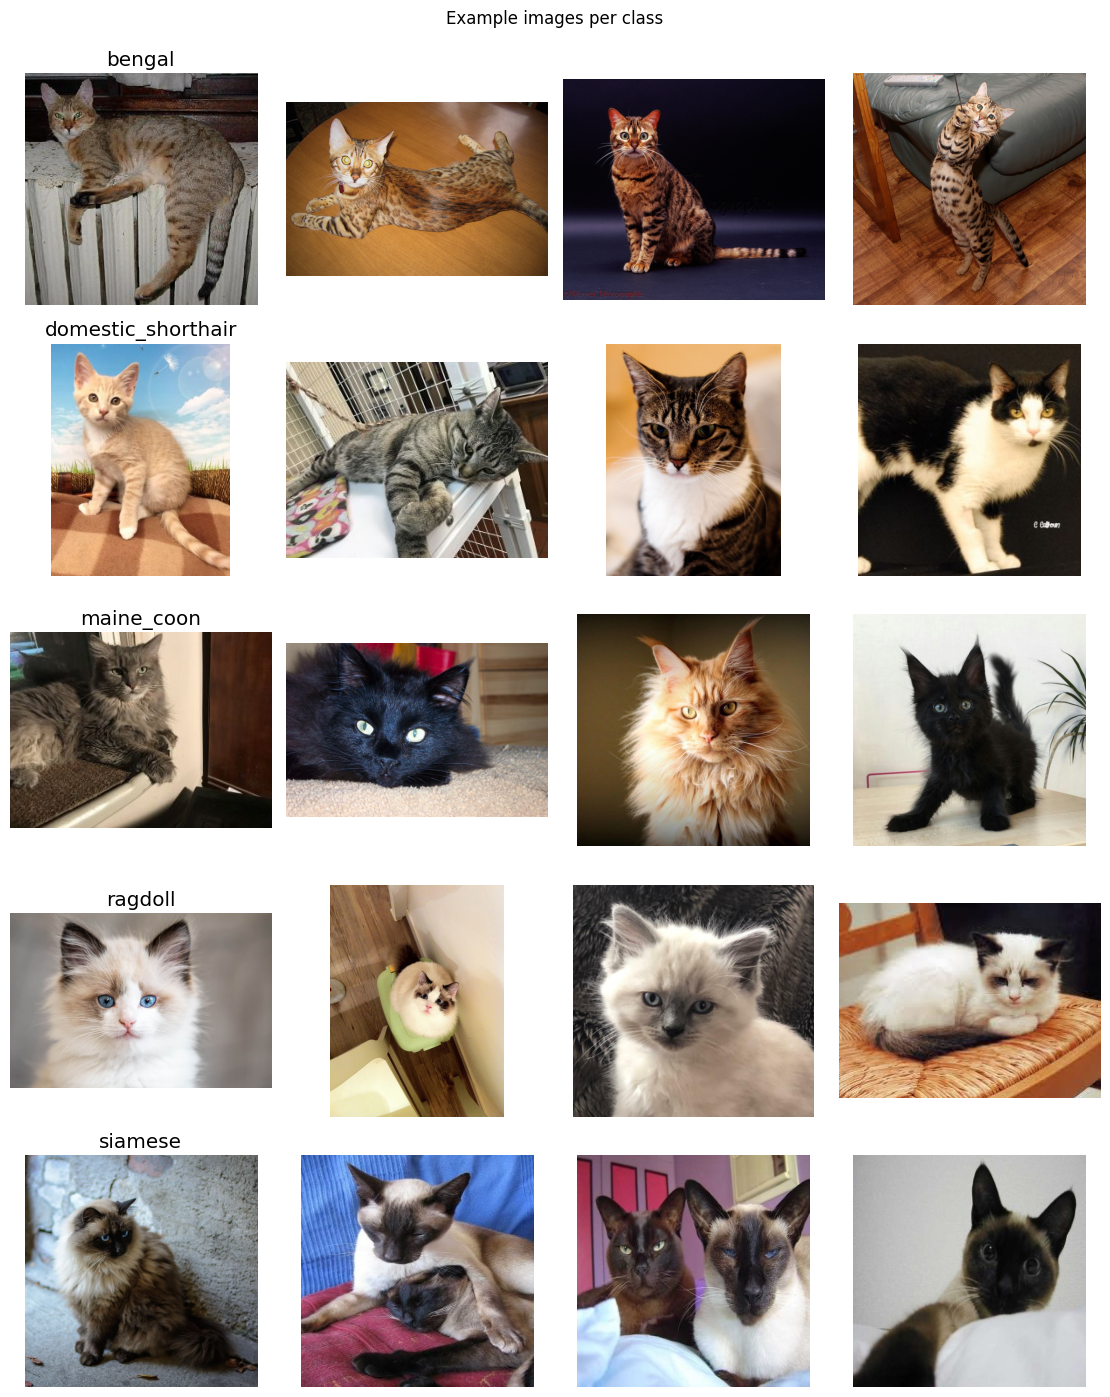

In [94]:
# Examples & labels (image grid)
def show_examples(df, per_class=4):
    labels = sorted(df["label"].unique())
    nrows, ncols = len(labels), per_class
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.8*ncols, 2.8*nrows))
    if nrows == 1: axes = np.array([axes])
    for r, lab in enumerate(labels):
        subset = df[df["label"]==lab]
        sample = subset.sample(min(per_class, len(subset)), random_state=42)
        for c, (_, row) in enumerate(sample.iterrows()):
            ax = axes[r, c] if ncols>1 else axes[r, 0]
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img); ax.set_axis_off()
            if c == 0: ax.set_title(lab)
    plt.suptitle("Example images per class", y=0.995)
    plt.tight_layout(); plt.show()

show_examples(meta, per_class=4)


We also plot RGB histograms for one image per class. That gives a basic view of brightness and color for single images.

Single-image histograms (one per class):


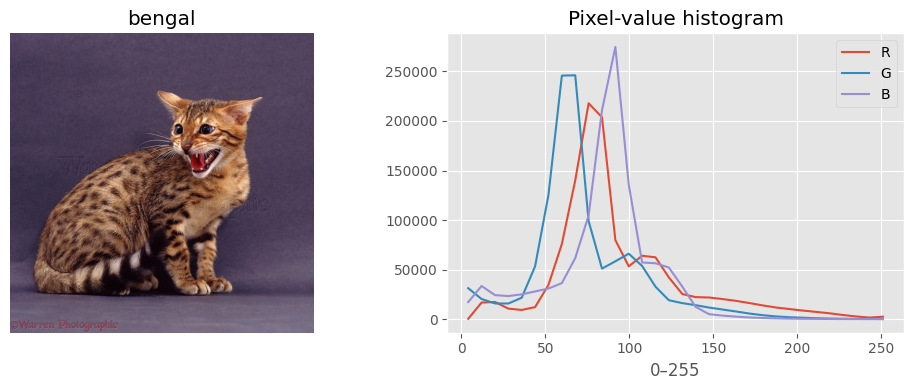

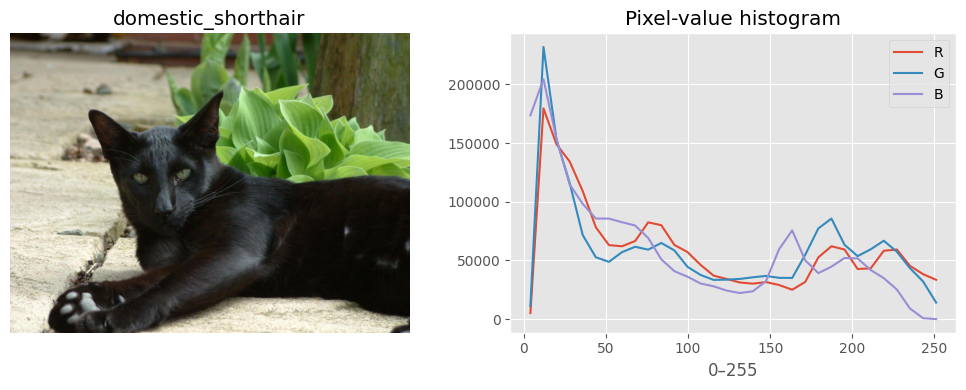

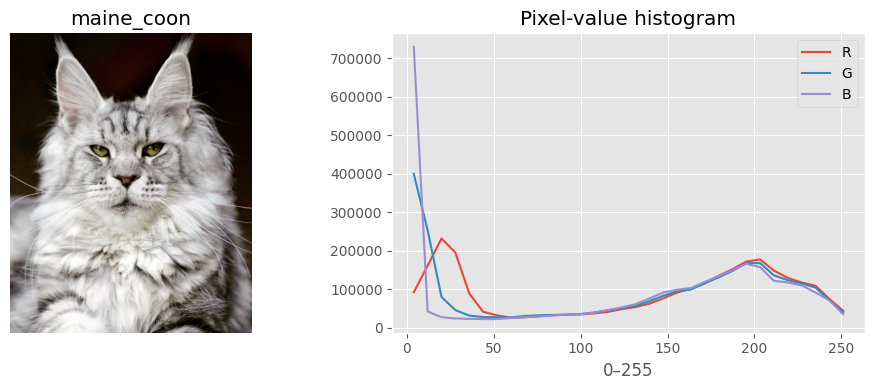

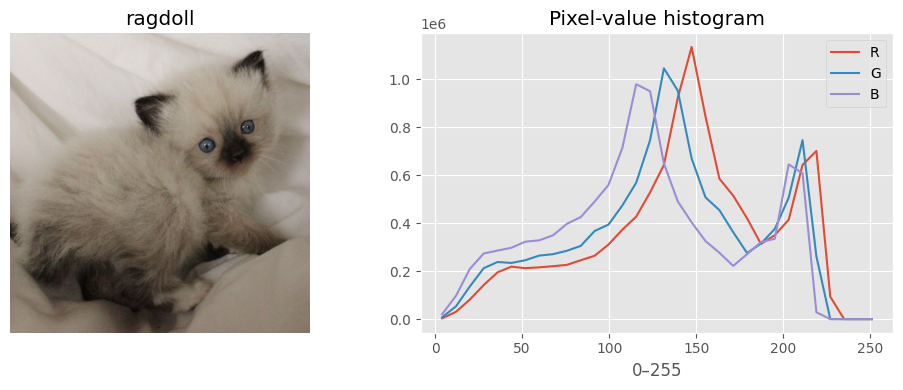

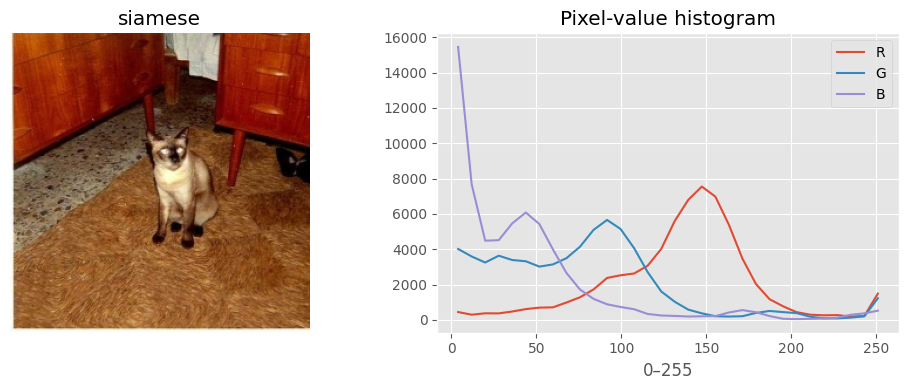

In [95]:
# Histograms on individual images
def plot_image_and_histogram(image_path, bins=32):
    im = Image.open(image_path).convert("RGB")
    arr = np.asarray(im, dtype=np.uint8)
    fig = plt.figure(figsize=(10,4))
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(im); ax1.set_axis_off(); ax1.set_title(Path(image_path).parent.name)
    ax2 = plt.subplot(1,2,2)
    for ch, name in enumerate(["R","G","B"]):
        hist, edges = np.histogram(arr[...,ch].ravel(), bins=bins, range=(0,255))
        centers = 0.5*(edges[1:]+edges[:-1])
        ax2.plot(centers, hist, label=name)
    ax2.set_title("Pixel-value histogram"); ax2.set_xlabel("0–255"); ax2.legend()
    plt.tight_layout(); plt.show()

print("Single-image histograms (one per class):")
for lab in sorted(meta["label"].unique()):
    ex = meta[meta["label"]==lab]
    if len(ex):
        plot_image_and_histogram(ex.iloc[0]["path"], bins=32)


The above data analysis gives us a clear picture of what the dataset includes. We know the folder layout for loaders, the class balance, typical image sizes and aspect ratios, and the formats/color modes. Hopefully this will help us be more prepared for the later challenge of actually training a model.

In [96]:
import shutil
from PIL import Image, ImageOps

def standardize_images(
    df, 
    out_root="CatData/_tmp_standardized",
    target_size=(299,299),
    out_format="JPEG",
    quality=95,
    preserve_structure=True,
    letterbox=False,
    bg_color=(0,0,0),
    val_fraction=0.10,
    test_fraction=0.10,
    random_state=42,
    balance_to_min_class=False,   # <--- NEW
):
    """
    df: metadata dataframe with columns 'path','label'
    ...
    """

    assert 0 <= val_fraction < 1
    assert 0 <= test_fraction < 1
    assert val_fraction + test_fraction < 1, "val_fraction + test_fraction must be < 1"

    df = df.copy()

    # --- NEW: balance to smallest class ---
    if balance_to_min_class:
        counts = df['label'].value_counts()
        min_count = counts.min()
        df = (
            df
            .groupby('label', group_keys=False)
            .apply(lambda g: g.sample(min_count, random_state=random_state))
            .reset_index(drop=True)
        )
        print(f"Balanced dataset: {len(df)} images "
              f"({min_count} per class, {df['label'].nunique()} classes)")

    # Clean output directory
    out_root = Path(out_root)
    if out_root.exists():
        shutil.rmtree(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(random_state)

    # Decide train/val/test assignment
    rand_vals = rng.random(len(df))

    df["split"] = "train"  # default
    df.loc[rand_vals < test_fraction, "split"] = "test"
    df.loc[
        (rand_vals >= test_fraction) & (rand_vals < test_fraction + val_fraction),
        "split"
    ] = "val"

    counts = 0
    for _, row in df.iterrows():
        src = Path(row["path"])
        label = row["label"]
        split = row["split"]

        try:
            with Image.open(src) as im:
                im = im.convert("RGB")

                if letterbox:
                    im.thumbnail(target_size, Image.Resampling.LANCZOS)
                    canvas = Image.new("RGB", target_size, bg_color)
                    off_x = (target_size[0] - im.width) // 2
                    off_y = (target_size[1] - im.height) // 2
                    canvas.paste(im, (off_x, off_y))
                    out_im = canvas
                else:
                    out_im = ImageOps.fit(im, target_size, Image.Resampling.LANCZOS)

                split_dir = out_root / split
                subdir = split_dir / label if preserve_structure else split_dir
                subdir.mkdir(parents=True, exist_ok=True)

                out_name = src.stem + "." + ("jpg" if out_format.upper()=="JPEG" else out_format.lower())
                out_path = subdir / out_name

                save_kwargs = {}
                if out_format.upper() == "JPEG":
                    save_kwargs.update({"quality": quality, "optimize": True})

                out_im.save(out_path, out_format, **save_kwargs)
                counts += 1

        except Exception as e:
            print(f"Failed {src}: {e}")

    print(f"Standardized {counts} images -> {out_root}")
    print(f"Train size: {(df['split']=='train').sum()}")
    print(f"Val size:   {(df['split']=='val').sum()}")
    print(f"Test size:  {(df['split']=='test').sum()}")

    return df

meta_split = standardize_images(
    meta,
    target_size=(299, 299),
    out_format="JPEG",
    letterbox=False,
    val_fraction=0.10,
    test_fraction=0.10,
    balance_to_min_class=True,
)

C:\Users\perhi\AppData\Local\Temp\ipykernel_10288\1203097361.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_count, random_state=random_state))


Balanced dataset: 2600 images (520 per class, 5 classes)
Standardized 2600 images -> CatData\_tmp_standardized
Train size: 2060
Val size:   282
Test size:  258


# Choice of ML algorithm

For this project we frame cat-breed recognition as a supervised multiclass image-classification problem as each input image is paired with a known breed label, and the model must assign one of five possible classes (Bengal, Domestic Shorthair, Maine Coon, Ragdoll, Siamese). Because the input data are images with a clear two-dimensional spatial structure, we use computer-vision methods rather than generic tabular algorithms. Convolutional neural networks (CNNs) are the standard choice for image recognition on large datasets such as ImageNet.

CNNs are well suited to this task because they exploit the topology of image data through local receptive fields and weight sharing. This allows the network to learn translation-invariant features, so if the cat is shifted, rotated, or appears at a different scale, the same convolutional filters can still detect relevant visual patterns such as edges, fur textures, and facial structures. Instead of relying on hand-crafted features like manually defined color histograms or shape descriptors, the CNN automatically learns a hierarchy of representations, from low-level edges and corners in the early layers to higher-level concepts such as ears, eyes, and overall head shape in deeper layers. This makes CNNs more robust to variations in pose, lighting, and background that characterize real-world cat photos.

Training a deep CNN from scratch usually requires very large labeled datasets and substantial computational resources. Our cat-breed dataset is much smaller (3649) than ImageNet (14 million), so directly learning all weights from random initialization would increase the risk of overfitting and lengthen training time. To address this, we adopt transfer learning, which is standard practice for image classification when data are limited. We reuse a pre-trained CNN, Inception v3, which is originally trained on more than one million images and 1,000 object categories from the ImageNet dataset. Inception v3 is a deep, optimized CNN architecture that combines convolutional, pooling, and “Inception” modules to achieve strong accuracy without using too much computational powers.

In our transfer-learning setup, the lower and middle layers of the pre-trained Inception v3 model are frozen, because they capture generic visual features such as edges, textures, and simple shapes that are useful for almost any image domain. Only the final classification layers are replaced and retrained on our five cat-breed classes. This approach drastically reduces training time and data requirements while typically improving generalization compared with training a similar-sized network from scratch on a small dataset.

We implement our model in Python using TensorFlow and its high-level Keras API. Keras provides a simple way to define, train, and evaluate deep learning models, while TensorFlow handles the underlying computation efficiently on both CPU and GPU. This framework also offers built-in support for loading pre-trained models such as Inception v3 and makes it straightforward to fine-tune them for our specific cat-breed classification task.


## Sources 

- [Szegedy, C. et al. “Rethinking the Inception Architecture for Computer Vision.” CVPR, 2016.](https://arxiv.org/abs/1512.00567)  
- [ImageNet Project. “About ImageNet.”](https://www.image-net.org/about.php)  
- [Kaggle. “Inception V3 Model”](https://www.kaggle.com/datasets/generalerror/torchvision-inception-v3-imagenet-pretrained)  
- [Tensorflow Learn. “Convolutional Neural Network (CNN)”](https://www.tensorflow.org/tutorials/images/cnn)  
- [Wikipedia. “Convolutional Neural Network.”](https://en.wikipedia.org/wiki/Convolutional_neural_network)  
- [Wikipedia. “Inception (deep learning architecture).”](https://en.wikipedia.org/wiki/Inceptionv3)  
- [Keras: Transfer learning & fine-tuning”](https://keras.io/guides/transfer_learning/)

# ML Data processing

In the following section we are going to use the data from the dataset section. The data is already been standardized with a width and height of 299. This data has also been randomly split into 3 ratios. Around 10% for validation, and 10% for tests. The rest is for training.

Our model is based on the InceptionV3 model from Keras but without the top, which is based on Imagenet's 1000 classes. These classes are things like busses, persons, toasters and such.
We want to replace it with images of cats, so that it can identify them.

In [97]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3 # type: ignore
from tensorflow.keras import layers, models # type: ignore

NUM_CAT_BREEDS = 5
width, height = 299, 299

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(width,height,3)
)

We set the base model, with the lower levels to be non trainable. The base model is based on edges, corners, colors, tectures and simple shapes. We dont want to train on this yet. This comes in the fine tuning part.

In [98]:
base_model.trainable = False

The below is defining the input tensor layer for the Tensorflow Keras model. It tells Keras that we are going to input images with the following shape. Width, height and color channels.

In [99]:
inputs = tf.keras.Input(shape=(width, height, 3)) # type: ignore

We introduce some augmentation which randomly flips, rotate and zooms the images during training. This ensures that the model can correctly identify the cats from multiple angles and zoom levels.

[Source](https://keras.io/api/layers/preprocessing_layers/image_augmentation/)

In [100]:
data_augmentation = tf.keras.Sequential([ # type: ignore
    tf.keras.layers.RandomFlip("horizontal"), # type: ignore
    tf.keras.layers.RandomRotation(.1), # type: ignore
    tf.keras.layers.RandomZoom(.1) # type: ignore
])

x = data_augmentation(inputs)

In [101]:
from tensorflow.keras.applications.inception_v3 import preprocess_input # type: ignore

The code below defines the architecture of a image classification model. `preprocess_input` makes our images into the format that the model requires.

[Source](https://stackoverflow.com/questions/47555829/preprocess-input-method-in-keras)

In [102]:
x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CAT_BREEDS, activation="softmax")(x)

model = models.Model(inputs, outputs)

In the compile step below, we tell Keras that we want to train the following model.

We use the [Adam](https://www.geeksforgeeks.org/deep-learning/adam-optimizer/) optimizer.
The learning rate defines how quickly the weights change when training.
The loss function uses Sparse Categorical Cross entropy. Later, the fit function uses the value from this function to update weights.

Lastly, the metrics used to calculate how often `y_pred` matches `y_true` shows how accurate out model is.

[Loss function Source](https://chatgpt.com/share/692ded69-4e78-8008-a390-97f99b81828e)

[Metrics source](https://keras.io/api/metrics/accuracy_metrics/)

In [103]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # type: ignore
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # type: ignore
    metrics=['accuracy']
)

Below we import the training, validation and test data with the keras utility `image_dataset_from_directory`.

In [104]:
IMG_SIZE = (width, height)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory( # type: ignore
    "CatData/_tmp_standardized/train",
    validation_split=.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory( # type: ignore
    "CatData/_tmp_standardized/val",
    validation_split=.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory( # type: ignore
    "CatData/_tmp_standardized/test",
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names)

Found 2059 files belonging to 5 classes.
Using 1648 files for training.
Found 282 files belonging to 5 classes.
Using 226 files for training.
Found 258 files belonging to 5 classes.
['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']


Below we we train the head with the training dataset.

We use Keras `EarlyStopping` callback to stop training when the validation loss which reflects how well the model performs on unseen real world data. The early stop happens if the validation loss have not improved for 8 epochs.

The fitting part, is where we train the head of the model. It uses the training dataset with the validation dataset. It will run for 20 epochs, if the early stopping doesn't stop it first.

[EarlyStopping source](https://keras.io/api/callbacks/early_stopping/)

[Validation Loss](https://www.geeksforgeeks.org/deep-learning/training-and-validation-loss-in-deep-learning/)

In [105]:
# Train the head
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

print("Number of epochs run:", len(history.history["loss"]))
print("Best epoch according to callback:", early_stop.best_epoch)
print("Argmin of val_loss:", np.argmin(history.history["val_loss"]))

Epoch 1/20


C:\Users\perhi\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


52/52 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6893 - loss: 0.8028 - val_accuracy: 0.8673 - val_loss: 0.4583
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8064 - loss: 0.4894 - val_accuracy: 0.8673 - val_loss: 0.4225
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8507 - loss: 0.4195 - val_accuracy: 0.8717 - val_loss: 0.3683
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8683 - loss: 0.3776 - val_accuracy: 0.8673 - val_loss: 0.3628
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8853 - loss: 0.3387 - val_accuracy: 0.8584 - val_loss: 0.3868
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8871 - loss: 0.3321 - val_accuracy: 0.8628 - val_loss: 0.4084
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8902 - loss: 0.3032 - val_accuracy: 0.8805 - val_loss: 0.4134
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9023 - loss: 0.2802 - val_accuracy: 0.8805 - val_loss: 0.3604
Epo

## Manual test

For small testing we decieded to try and see how well the model performed on random images from the test dataset, that was split in the dataset section.

We utilize a small `TestImage` funciton, that takes an image and predicts with the model and outputs the the data in a sorted manner. Another function `getRandTestImage` fetches the image from the test folder and returns the path to it.

In [106]:
def TestImage(imgpath, target_size=IMG_SIZE):
    img = tf.keras.utils.load_img(imgpath, target_size=target_size) # type: ignore

    img_array = tf.keras.utils.img_to_array(img) # type: ignore
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)[0]

    for name, p in sorted(zip(class_names, predictions), key=lambda x: -x[1]):
        print(f"{name:20s} {p:.3f}")


In [107]:
import glob
import random

def getRandTestImage(breed):
    return random.choice(glob.glob(f"CatData/_tmp_standardized/test/{breed}/*"))

In [108]:
TestImage(getRandTestImage("ragdoll"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
ragdoll              0.828
siamese              0.171
maine_coon           0.001
domestic_shorthair   0.000
bengal               0.000


In [109]:
TestImage(getRandTestImage("maine_coon"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
maine_coon           0.922
domestic_shorthair   0.074
bengal               0.003
ragdoll              0.001
siamese              0.000


In [110]:
TestImage(getRandTestImage("bengal"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
bengal               0.970
domestic_shorthair   0.030
maine_coon           0.000
siamese              0.000
ragdoll              0.000


In [111]:
TestImage(getRandTestImage("siamese"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
siamese              0.998
ragdoll              0.002
domestic_shorthair   0.000
bengal               0.000
maine_coon           0.000


In [112]:
TestImage(getRandTestImage("domestic_shorthair"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
maine_coon           0.547
domestic_shorthair   0.290
bengal               0.162
ragdoll              0.001
siamese              0.000


And for good measure and also a little for fun we can also easlily give the model a whatever picture of our choosing, below we try it out with a picture of my (Per) persian cat and a random ragdoll cat found on the internet.

In [45]:
TestImage("Thorkild.JPG", (IMG_SIZE))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
ragdoll              0.999
maine_coon           0.001
siamese              0.000
domestic_shorthair   0.000
bengal               0.000


In [62]:
TestImage("Ragdoll.jpg", (IMG_SIZE))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
ragdoll              0.996
siamese              0.004
bengal               0.000
domestic_shorthair   0.000
maine_coon           0.000


For the manual testing, its easy to see that its most confident with siamese and has the lowest confidense in domestic shorthair. In performance metrics we will dive deeper into the performance of the model.

[Source ChatGPT (pretty long)](https://chatgpt.com/share/69287e45-6040-8008-8594-a1ac4f4b8162)

# Performance metrics

# Under- and overfitting
here

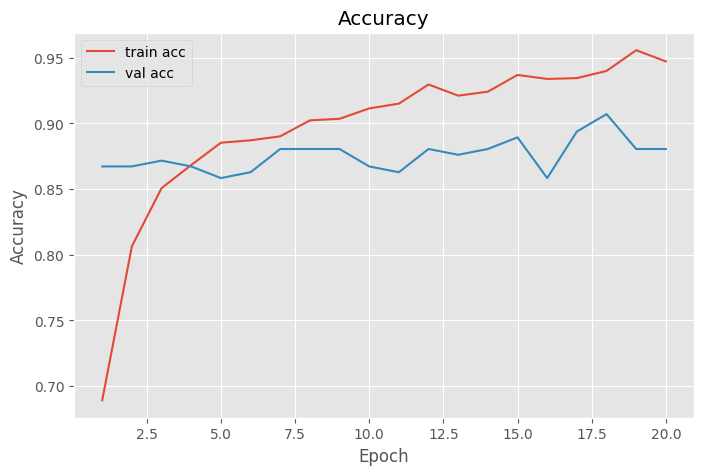

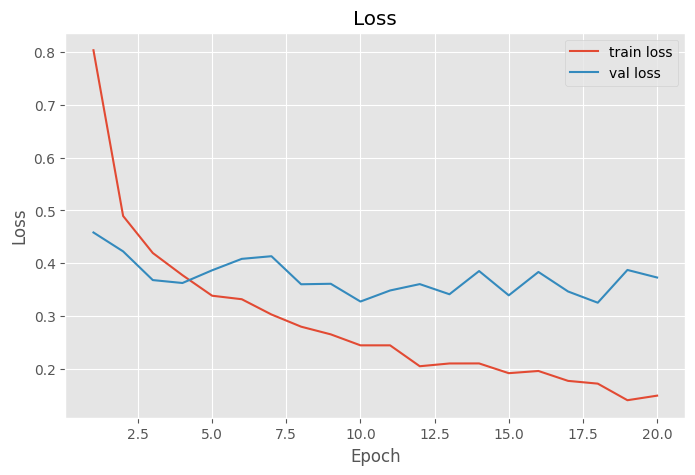

In [113]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs, acc, label="train acc")
    plt.plot(epochs, val_acc, label="val acc")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")

    plt.figure()
    plt.plot(epochs, loss, label="train loss")
    plt.plot(epochs, val_loss, label="val loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")

plot_history(history)


In [114]:
print("Number of epochs run: ", len(history.history["loss"]))
print("Best epoch:", early_stop.best_epoch)

Number of epochs run:  20
Best epoch: 17


As seen above, the `EarlyStopping` based on validation loss, chose epoch <NUMBER> as the best place to stop, to not overfit.

It ran a total of <NUMBER> epochs.

# Optimizations and improvements
## Confusion matrix
To evaluate and improve the performance of our CNN, we generated a confusion matrix after the initial training phase. Given that our accuracy provided an insight in the models performance itself, we wanted more evidence and also to identify errors that were not necessarily visible in the accuracy itself.
The confusion matrix showed the number of correct and incorrect predictions for each class, indicating which classes the model confused most frequently. By looking at the off-diagonal values in the confusion matrix, we quickly identified patterns like misclassification in terms of for instance, underrepresented data that was wrongfully predicted most often.

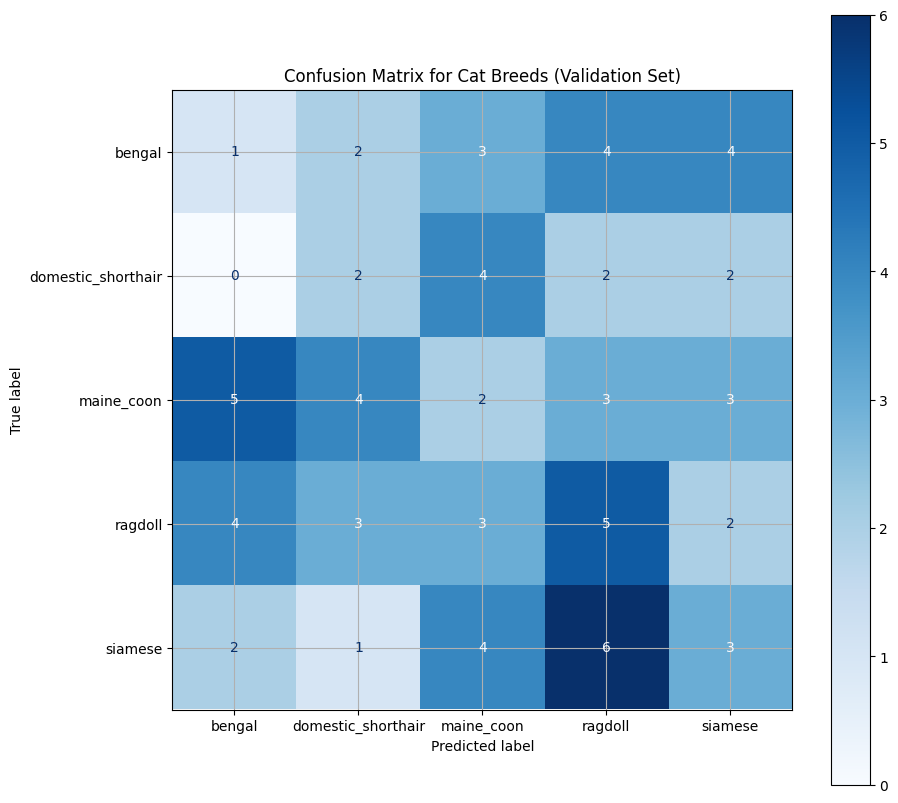


In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

def createConfusionMatrix(model):
    y_true = []
    for images, labels in test_ds:
        y_true.extend(labels.numpy())

    # Model true labels as NumPy array    
    y_true = np.array(y_true)
    print(f"y_true shape: {y_true.shape}")

    # Model Predictions
    y_pred_raw = model.predict(test_ds)
    print(f"y_pred_raw shape: {y_pred_raw.shape}")

    # Model Predictions as classes
    y_pred = np.argmax(y_pred_raw, axis=1)
    print(f"y_pred shape: {y_pred.shape}")

    # Generating the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Show matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=class_names
    )
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap=plt.cm.Blues) # type: ignore
    plt.title("Confusion Matrix for Cat Breeds (Validation Set)")
    plt.show()

def createClassificationReport(model):
    y_true = []
    for images, labels in test_ds:
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)
    y_pred_proba = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Per-class F1
    per_class_f1 = f1_score(y_true, y_pred, average=None)
    
    # Create dictionary for per-class F1 scores
    f1_scores_dict = {}
    for cls_name, f1 in zip(class_names, per_class_f1):
        print(f"{cls_name}: F1 = {f1:.4f}")
        f1_scores_dict[cls_name] = f1
    
    # Macro and weighted F1
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"\nMacro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    
    # Full classification report
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Return all F1 scores
    return {
        'per_class': f1_scores_dict,
        'macro': macro_f1,
        'weighted': weighted_f1
    }


During the evaluation of the model above, our matrix appeared inconsistent with the performance we observed with the model. To troubleshoot, we decided to review the pipeline, where we discovered that we were accidentally shuffling the validation labels before plotting the data. Therefore, the confusion matrix did not reflexct the classification behaviour of the model.
After identifying the issue and removing the shuffle, we regenerated the confusion matrix with the newly aligned labels:



y_true shape: (258,)
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
y_pred_raw shape: (258, 5)
y_pred shape: (258,)


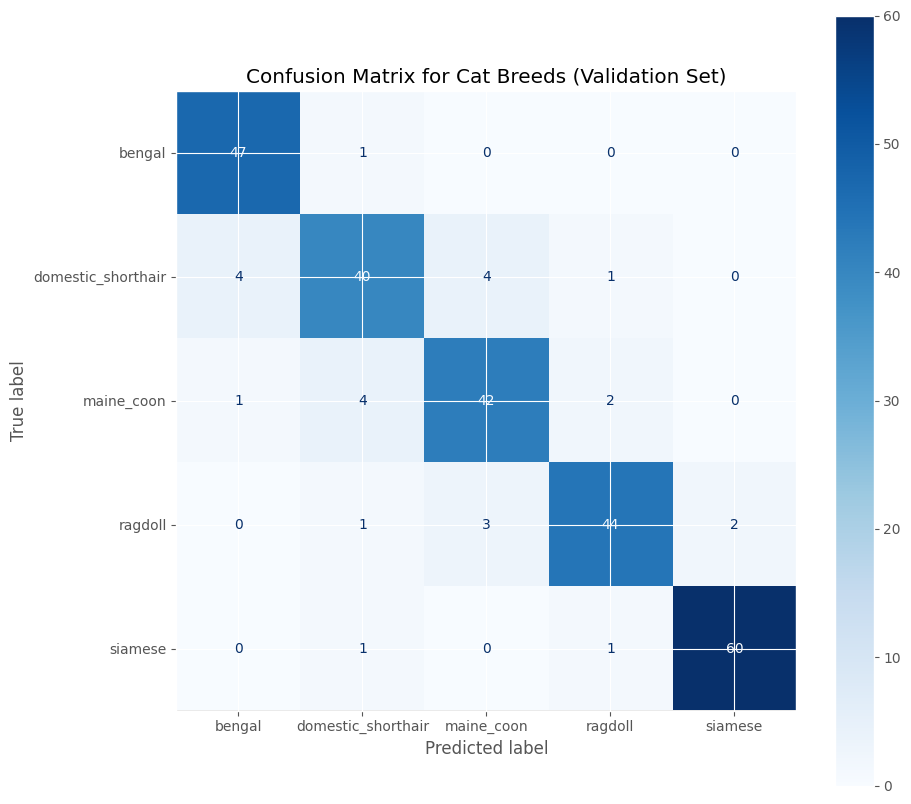

In [116]:
createConfusionMatrix(model=model)

With a more accurate confusion matrix as seen above, we could tell that the model was learning effectively, but we wanted even better performance. To further improve the model, we tried increasing the number of epochs and trained it for up to 500 epochs. After doing so, we realised that the improvement stopped after reaching somewhere between 8-16 epochs and going beyond that would essentially lead to overfitting.

In [117]:
baseline_model_scores = createClassificationReport(model)

bengal: F1 = 0.9400
domestic_shorthair: F1 = 0.8333
maine_coon: F1 = 0.8571
ragdoll: F1 = 0.8980
siamese: F1 = 0.9677

Macro F1:    0.8992
Weighted F1: 0.9025

Classification report:
                    precision    recall  f1-score   support

            bengal       0.90      0.98      0.94        48
domestic_shorthair       0.85      0.82      0.83        49
        maine_coon       0.86      0.86      0.86        49
           ragdoll       0.92      0.88      0.90        50
           siamese       0.97      0.97      0.97        62

          accuracy                           0.89       258
         macro avg       0.89      0.88      0.88       258
      weighted avg       0.89      0.89      0.89       258



From the classification report above, it tells us that the overall accuracy of the model is ~<NUMBER>% across the 5 cat breeds, with it performing best on siamese cats with a F1 score of ~<NUMBER>. This could be because of their destinctive look. It performs the worst on Domestic Shorthair, with a F1 score of ~<NUMBER>, likely because of its more variable look compared to the other cat breeds.

This was just the baseline model, we also tried fine-tuning the deeper levels of the model. This part is described in the section below.

In the end, we were happy with the overall performance of the model, and the outcome of the confusion matrix.

### Grad-CAM
To find out why there were small errors showing in the confusion matrix, we decided to analyse the CNN by using a heatmap, so we could learn where the model was wrong in terms of its predictions...

### Fine tuning the model

Our model is already excellent according to the overall accuracy, but we wanted to experiment with fine-tuning, as an increase in the F1 score for domestic shorthair would be cool to achieve. Fine-tuning allows us to adapt the pre-trained InceptionV3s higher level features to look for cat breed specific features, rather than relying on the generic features given by ImageNet.

We chose the 249th layer, as the Keras documentation recommends this when doing transfer learning on a new set of classes. If this layer height is off, then it could result in loss in features from the original InceptionV3 model. The layer is also called "mixed8", which is why we look for the layer name in the code below.

The learning rate for fine-tuning should be much lower than when training the original model. This is because the pre-trained weights from InceptionV3 are already optimized and good at visual feature extraction. Using a high learning rate would cause large weight updates that could distrupt the already learned features. The lower rate ensures only small adjustments to the models existing knowledge and allowing it to gradually adapt to our cat breed dataset.

We also tried saving the weights from the non-fine-tuned model and "Brute forcing" the fine tuning of layers between 240 and 255. This took around 1 hour to complete on the GPU cluster. But what we learned was, that running this multiple times gave us results around 245-252, which confirms the Keras documentation of finetuning from layer 249 and up. This experiment is documented in the appendix.

[Source](https://chatgpt.com/share/692e003a-7c3c-8008-8ebf-8b2edd47a194)

[Keras Applications](https://keras.io/api/applications/)

[Claude writing help](https://claude.ai/share/fdc3d903-768e-4411-859b-a73b608c1501)


In [118]:
# Fine tuning the top of InceptionV3
base_model.trainable = False

# Unfreeze from 'mixed8'
set_trainable = False
for layer in base_model.layers:
    if layer.name == "mixed8":
        set_trainable = True
    layer.trainable = set_trainable

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # type: ignore
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[fine_tune_early_stop]
)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8617 - loss: 0.4027 - val_accuracy: 0.8274 - val_loss: 0.6495
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9642 - loss: 0.1058 - val_accuracy: 0.9071 - val_loss: 0.3244
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9897 - loss: 0.0349 - val_accuracy: 0.9027 - val_loss: 0.3878
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.8982 - val_loss: 0.4965
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9909 - loss: 0.0257 - val_accuracy: 0.8850 - val_loss: 0.5326
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9945 - loss: 0.0214 - val_accuracy: 0.8894 - val_loss: 0.4350
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9945 - loss: 0.0166 - val_accuracy: 0.9115 - val_loss: 0.4380
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9945 - loss: 0.0194 - val_accuracy: 0.9071 - val_loss:

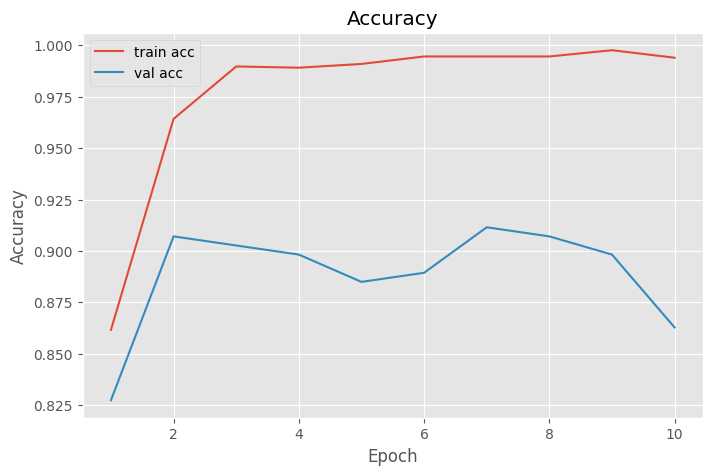

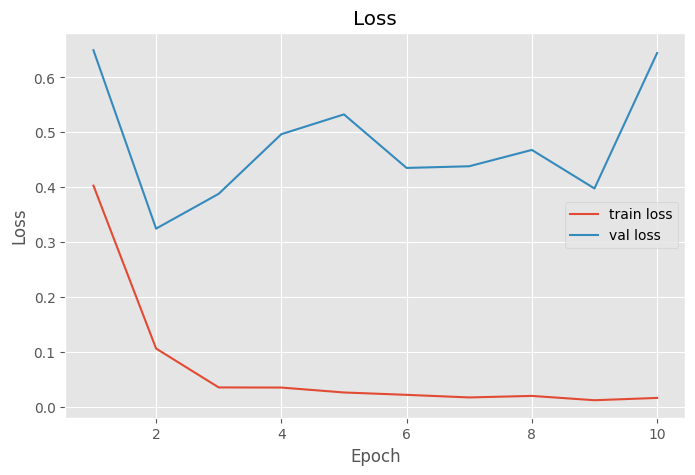

In [119]:
plot_history(fine_tune_history)

In [120]:
print("Number of epochs run: ", len(fine_tune_history.history["loss"]))
print("Best epoch:", fine_tune_early_stop.best_epoch)

Number of epochs run:  10
Best epoch: 1


Confusion matrix after fine tuning:

y_true shape: (258,)
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
y_pred_raw shape: (258, 5)
y_pred shape: (258,)


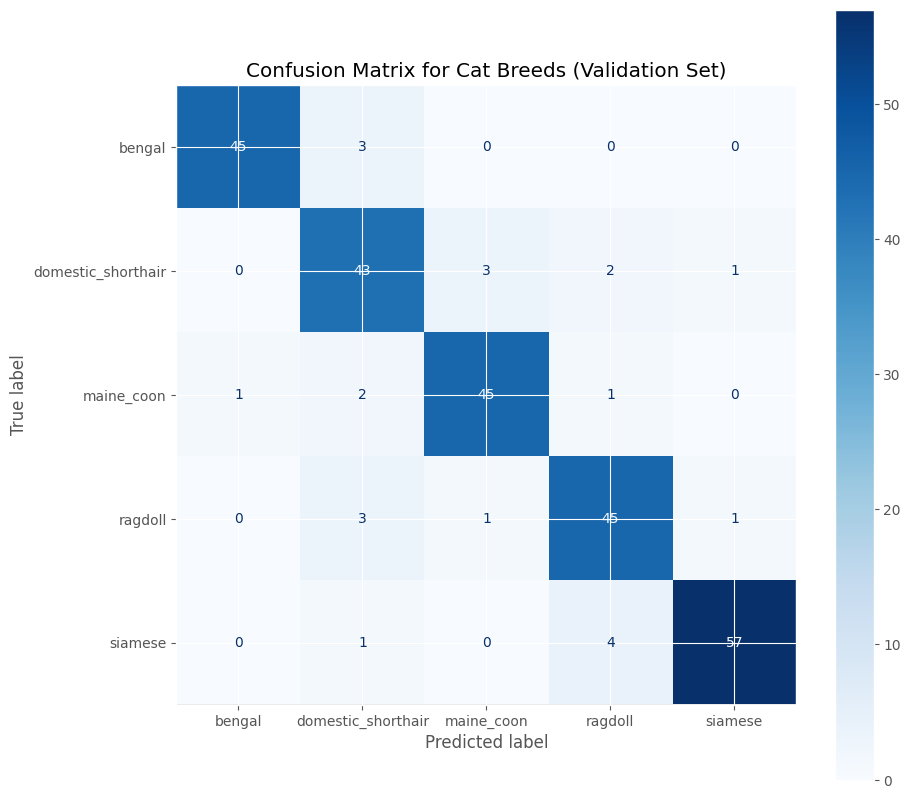

In [121]:
createConfusionMatrix(model)

In [122]:
finetuned_model_scores = createClassificationReport(model)

bengal: F1 = 0.9574
domestic_shorthair: F1 = 0.8515
maine_coon: F1 = 0.9184
ragdoll: F1 = 0.8824
siamese: F1 = 0.9421

Macro F1:    0.9104
Weighted F1: 0.9117

Classification report:
                    precision    recall  f1-score   support

            bengal       0.98      0.94      0.96        48
domestic_shorthair       0.83      0.88      0.85        49
        maine_coon       0.92      0.92      0.92        49
           ragdoll       0.87      0.90      0.88        50
           siamese       0.97      0.92      0.94        62

          accuracy                           0.91       258
         macro avg       0.91      0.91      0.91       258
      weighted avg       0.91      0.91      0.91       258



Comparison between f1 scores from baseline to finetuned. Code helped with by [Claude](https://claude.ai/share/87bd09c6-a8fb-4b1c-b4d7-34019419912c)

In [123]:
print("Comparison (Fine-tuned - Baseline):")
for cls_name in class_names:
    baseline_f1 = baseline_model_scores['per_class'][cls_name]
    finetuned_f1 = finetuned_model_scores['per_class'][cls_name]
    diff = finetuned_f1 - baseline_f1
    print(f"{cls_name}: {baseline_f1:.4f} → {finetuned_f1:.4f} ({diff:+.4f})")

print(f"\nMacro F1: {baseline_model_scores['macro']:.4f} → {finetuned_model_scores['macro']:.4f} ({finetuned_model_scores['macro'] - baseline_model_scores['macro']:+.4f})")
print(f"Weighted F1: {baseline_model_scores['weighted']:.4f} → {finetuned_model_scores['weighted']:.4f} ({finetuned_model_scores['weighted'] - baseline_model_scores['weighted']:+.4f})")


Comparison (Fine-tuned - Baseline):
bengal: 0.9400 → 0.9574 (+0.0174)
domestic_shorthair: 0.8333 → 0.8515 (+0.0182)
maine_coon: 0.8571 → 0.9184 (+0.0612)
ragdoll: 0.8980 → 0.8824 (-0.0156)
siamese: 0.9677 → 0.9421 (-0.0256)

Macro F1: 0.8992 → 0.9104 (+0.0111)
Weighted F1: 0.9025 → 0.9117 (+0.0091)


# Performance score F1

$F_1=\frac{2pr}{p+r}$

# Training analysis

In [124]:
# Source: https://pyimagesearch.com/2019/06/03/fine-tuning-with-keras-and-deep-learning/
def plot_training(H, N):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
	plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
	plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
	plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
	plt.title("Training Loss and Accuracy")
	plt.xlabel("Epoch #")
	plt.ylabel("Loss/Accuracy")
	plt.legend(loc="lower left")

In the below chart we see

**Training loss (train_loss)**: Starts around 0.80 and drops to around 0.14. This indicates that the model is improving on the training set.

**Validation loss (val_loss)**: Starts around 0.4 but drops to 0.35 but fluctuates a lot. Around 12-13 it spikes which suggests that the model begins to overfit, which means the model begins to memoize the training data better than unseen data.

**Training accuracy (train_acc)**: Starts around 0.69 and improves to 0.93. This is common in fine-tuning models or that the dataset is easy.

**Validation accuracy (val_acc)**: Staus around 0.85 to 0.90, which means the model generalizes well.

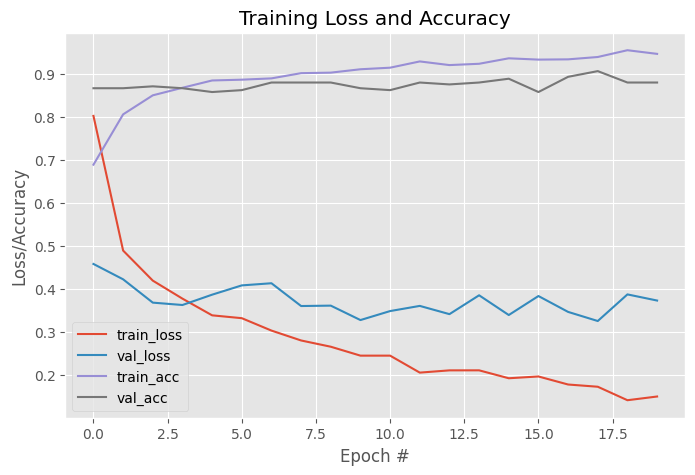

In [125]:
plot_training(history, len(history.history["loss"]))

**Training loss (train_loss)**: Starts around 0.55 but drops to 0.14 which is typical for fine tuning when the learning rate is small.

**Validation loss (val_loss)**: Is stable, which means the model is not overfitting during this fine tuning.

**Training accuracy (train_acc)**: Starts at around 0.8 but goes to close to 1.00, which means the model becomes confident in the training data.

**Validation accuracy (val_acc)**: PAS

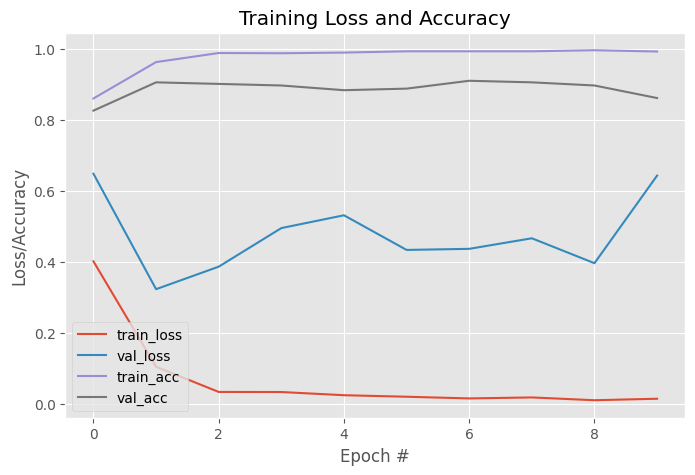

In [126]:
plot_training(fine_tune_history, len(fine_tune_history.history["loss"]))

Performance 

[plot_training](https://chatgpt.com/share/692e14cf-ba68-8008-a6c5-48d940c703f1)

# Conclusion
In this project we set out to make a image-classification model that can predict a cat's breed from a photo. Using a small to medium sized dataset, we analyzed the image format, color modes, resolutions and aspect ratios. We standardized the dataset to be 299x299 and split the dataset into train, validation and test splits. This way we decided to split the dataset proved effective, as we easily could add more images to the dataset.

Transfer learning with InceptionV3 was effective. More than we expected. By freezing the base and training the head we achieved high accuracy from the start, with Siamese cats being the most recognizable from our model. EarlyStopping prevented overfitting, and confusion matrixes showed us that we should not shuffle labels, which was a teachable moment for us. The manual tests were a fun way to get our hands dirty with the model and see that it is actually predicting with high confidence.

Overall, we believe that this model meets the initial goal. The model is accurate and easy to extend. 





## CHATTEN
In this end-to-end project, we set out to build a modular image-classification pipeline that can predict a cat’s breed from a single photo and scale to new classes with minimal changes. Using a curated dataset (Kaggle Cat’s Breed, CatBreedsRefined-7k, and Siamese cat images), we analyzed image formats, color modes, resolutions, and aspect ratios, standardized inputs to 299×299, and created reproducible train/val/test splits. The directory-per-breed structure and balanced sampling helped control class imbalance while keeping the pipeline simple and extensible.

Technically, transfer learning with InceptionV3 proved effective: freezing the base, training a lightweight head, and then fine-tuning upper layers (“mixed8” and above) yielded strong accuracy and macro-F1, with the best per-class performance on visually distinctive breeds like Siamese and the weakest on Domestic Shorthair, which is more visually variable. EarlyStopping and careful learning-rate selection prevented overfitting, and the confusion matrix plus per-class F1 clarified where the model confused look-alike classes. The manual tests and metrics aligned after removing label shuffling in evaluation, reinforcing the importance of a clean, deterministic pipeline.

Overall, the system meets the initial goal: it is accurate, transparent (via confusion matrix and reports), and easy to extend (drop-in folders, re-run preprocessing, retrain/fine-tune). Future work could include: stronger augmentation to reduce background bias, Grad-CAM for interpretability, class-aware sampling, and targeted data collection for weaker classes (e.g., Domestic Shorthair). With these improvements, the pipeline can scale to more breeds and maintain reliable generalization in realistic, diverse images.

# Appendix

## Brute forcing fine-tuning layer code

### Saving the weights:
```python
model.save("cats_feature_extractor.keras")
```

### Brute force code
```python
# FIND OPTIMAL FINE TUNING HEIGHT
import tensorflow as tf

def run_fine_tune(fine_tune_from, lr=1e-5):
    # unfreeze from chosen layer
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_from]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        callbacks=[early_stop]  # same EarlyStopping as before
    )
    return max(history_ft.history["val_accuracy"])


candidates = list(range(240, 256))
results = {}
for ft in candidates:
    # reload baseline each time so each run starts from same weights
    model = tf.keras.models.load_model("cats_feature_extractor.keras")
    base_model = model.get_layer("inception_v3")

    best_val_acc = run_fine_tune(ft, lr=1e-5)
    results[ft] = best_val_acc
    print(ft, best_val_acc)
```

### Results
```bash
Epoch 1/5
52/52 [==============================] - 23s 181ms/step - loss: 0.2298 - accuracy: 0.9266 - val_loss: 0.3325 - val_accuracy: 0.8717
Epoch 2/5
52/52 [==============================] - 6s 117ms/step - loss: 0.1405 - accuracy: 0.9575 - val_loss: 0.3332 - val_accuracy: 0.8938
Epoch 3/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0961 - accuracy: 0.9703 - val_loss: 0.3441 - val_accuracy: 0.8938
Epoch 4/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0716 - accuracy: 0.9812 - val_loss: 0.3450 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 117ms/step - loss: 0.0491 - accuracy: 0.9891 - val_loss: 0.3403 - val_accuracy: 0.8938
240 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 19s 154ms/step - loss: 0.2342 - accuracy: 0.9229 - val_loss: 0.3131 - val_accuracy: 0.8938
Epoch 2/5
52/52 [==============================] - 6s 116ms/step - loss: 0.1323 - accuracy: 0.9654 - val_loss: 0.3415 - val_accuracy: 0.8894
Epoch 3/5
52/52 [==============================] - 6s 119ms/step - loss: 0.0936 - accuracy: 0.9739 - val_loss: 0.3280 - val_accuracy: 0.9071
Epoch 4/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0675 - accuracy: 0.9830 - val_loss: 0.3467 - val_accuracy: 0.8982
Epoch 5/5
52/52 [==============================] - 6s 115ms/step - loss: 0.0492 - accuracy: 0.9891 - val_loss: 0.3554 - val_accuracy: 0.8982
241 0.9070796370506287
Epoch 1/5
52/52 [==============================] - 19s 154ms/step - loss: 0.2115 - accuracy: 0.9320 - val_loss: 0.3108 - val_accuracy: 0.8894
Epoch 2/5
52/52 [==============================] - 6s 119ms/step - loss: 0.1478 - accuracy: 0.9587 - val_loss: 0.2999 - val_accuracy: 0.8982
Epoch 3/5
52/52 [==============================] - 7s 125ms/step - loss: 0.0949 - accuracy: 0.9727 - val_loss: 0.3052 - val_accuracy: 0.9027
Epoch 4/5
52/52 [==============================] - 6s 118ms/step - loss: 0.0689 - accuracy: 0.9824 - val_loss: 0.3339 - val_accuracy: 0.8938
Epoch 5/5
52/52 [==============================] - 6s 114ms/step - loss: 0.0444 - accuracy: 0.9909 - val_loss: 0.3559 - val_accuracy: 0.9027
242 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 19s 162ms/step - loss: 0.2345 - accuracy: 0.9229 - val_loss: 0.3148 - val_accuracy: 0.8982
Epoch 2/5
52/52 [==============================] - 6s 123ms/step - loss: 0.1465 - accuracy: 0.9587 - val_loss: 0.3133 - val_accuracy: 0.8938
Epoch 3/5
52/52 [==============================] - 6s 120ms/step - loss: 0.1051 - accuracy: 0.9721 - val_loss: 0.3208 - val_accuracy: 0.9027
Epoch 4/5
52/52 [==============================] - 6s 118ms/step - loss: 0.0732 - accuracy: 0.9818 - val_loss: 0.3188 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 115ms/step - loss: 0.0565 - accuracy: 0.9854 - val_loss: 0.3287 - val_accuracy: 0.8982
243 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 17s 131ms/step - loss: 0.2158 - accuracy: 0.9169 - val_loss: 0.3274 - val_accuracy: 0.8850
Epoch 2/5
52/52 [==============================] - 5s 90ms/step - loss: 0.1484 - accuracy: 0.9557 - val_loss: 0.3196 - val_accuracy: 0.8982
Epoch 3/5
52/52 [==============================] - 5s 93ms/step - loss: 0.1028 - accuracy: 0.9727 - val_loss: 0.3121 - val_accuracy: 0.8982
Epoch 4/5
52/52 [==============================] - 5s 91ms/step - loss: 0.0783 - accuracy: 0.9763 - val_loss: 0.3107 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 124ms/step - loss: 0.0564 - accuracy: 0.9860 - val_loss: 0.3751 - val_accuracy: 0.8761
244 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 18s 154ms/step - loss: 0.2111 - accuracy: 0.9363 - val_loss: 0.3296 - val_accuracy: 0.8982
Epoch 2/5
52/52 [==============================] - 6s 121ms/step - loss: 0.1392 - accuracy: 0.9600 - val_loss: 0.3251 - val_accuracy: 0.8894
Epoch 3/5
52/52 [==============================] - 6s 118ms/step - loss: 0.1013 - accuracy: 0.9697 - val_loss: 0.3378 - val_accuracy: 0.9027
Epoch 4/5
52/52 [==============================] - 6s 120ms/step - loss: 0.0749 - accuracy: 0.9818 - val_loss: 0.3369 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 119ms/step - loss: 0.0482 - accuracy: 0.9867 - val_loss: 0.3702 - val_accuracy: 0.8850
245 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 19s 156ms/step - loss: 0.2233 - accuracy: 0.9235 - val_loss: 0.3255 - val_accuracy: 0.8894
Epoch 2/5
52/52 [==============================] - 6s 123ms/step - loss: 0.1529 - accuracy: 0.9533 - val_loss: 0.3203 - val_accuracy: 0.8938
Epoch 3/5
52/52 [==============================] - 6s 118ms/step - loss: 0.1071 - accuracy: 0.9721 - val_loss: 0.3288 - val_accuracy: 0.8850
Epoch 4/5
52/52 [==============================] - 6s 117ms/step - loss: 0.0848 - accuracy: 0.9739 - val_loss: 0.3411 - val_accuracy: 0.8938
Epoch 5/5
52/52 [==============================] - 6s 119ms/step - loss: 0.0563 - accuracy: 0.9824 - val_loss: 0.3442 - val_accuracy: 0.8894
246 0.8938053250312805
Epoch 1/5
52/52 [==============================] - 20s 167ms/step - loss: 0.2121 - accuracy: 0.9308 - val_loss: 0.3129 - val_accuracy: 0.8938
Epoch 2/5
52/52 [==============================] - 7s 124ms/step - loss: 0.1509 - accuracy: 0.9508 - val_loss: 0.3104 - val_accuracy: 0.8982
Epoch 3/5
52/52 [==============================] - 7s 127ms/step - loss: 0.1029 - accuracy: 0.9745 - val_loss: 0.3100 - val_accuracy: 0.9027
Epoch 4/5
52/52 [==============================] - 7s 126ms/step - loss: 0.0753 - accuracy: 0.9806 - val_loss: 0.3172 - val_accuracy: 0.8938
Epoch 5/5
52/52 [==============================] - 7s 124ms/step - loss: 0.0459 - accuracy: 0.9885 - val_loss: 0.3283 - val_accuracy: 0.9027
247 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 18s 145ms/step - loss: 0.2306 - accuracy: 0.9254 - val_loss: 0.3140 - val_accuracy: 0.9027
Epoch 2/5
52/52 [==============================] - 6s 113ms/step - loss: 0.1426 - accuracy: 0.9563 - val_loss: 0.3082 - val_accuracy: 0.8982
Epoch 3/5
52/52 [==============================] - 6s 119ms/step - loss: 0.1029 - accuracy: 0.9703 - val_loss: 0.3176 - val_accuracy: 0.8894
Epoch 4/5
52/52 [==============================] - 6s 123ms/step - loss: 0.0625 - accuracy: 0.9897 - val_loss: 0.3183 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 122ms/step - loss: 0.0454 - accuracy: 0.9915 - val_loss: 0.3355 - val_accuracy: 0.9071
248 0.9070796370506287
Epoch 1/5
52/52 [==============================] - 19s 160ms/step - loss: 0.2240 - accuracy: 0.9278 - val_loss: 0.3348 - val_accuracy: 0.8761
Epoch 2/5
52/52 [==============================] - 6s 123ms/step - loss: 0.1359 - accuracy: 0.9581 - val_loss: 0.3242 - val_accuracy: 0.9027
Epoch 3/5
52/52 [==============================] - 6s 116ms/step - loss: 0.1012 - accuracy: 0.9703 - val_loss: 0.3339 - val_accuracy: 0.8982
Epoch 4/5
52/52 [==============================] - 6s 118ms/step - loss: 0.0779 - accuracy: 0.9806 - val_loss: 0.3462 - val_accuracy: 0.8982
Epoch 5/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0484 - accuracy: 0.9879 - val_loss: 0.3328 - val_accuracy: 0.8938
249 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 18s 158ms/step - loss: 0.2090 - accuracy: 0.9284 - val_loss: 0.3113 - val_accuracy: 0.9071
Epoch 2/5
52/52 [==============================] - 6s 116ms/step - loss: 0.1478 - accuracy: 0.9551 - val_loss: 0.3198 - val_accuracy: 0.8894
Epoch 3/5
52/52 [==============================] - 6s 117ms/step - loss: 0.1056 - accuracy: 0.9697 - val_loss: 0.3197 - val_accuracy: 0.8894
Epoch 4/5
52/52 [==============================] - 6s 117ms/step - loss: 0.0812 - accuracy: 0.9769 - val_loss: 0.3239 - val_accuracy: 0.9071
Epoch 5/5
52/52 [==============================] - 6s 117ms/step - loss: 0.0574 - accuracy: 0.9848 - val_loss: 0.3262 - val_accuracy: 0.9027
250 0.9070796370506287
Epoch 1/5
52/52 [==============================] - 18s 159ms/step - loss: 0.2173 - accuracy: 0.9266 - val_loss: 0.3287 - val_accuracy: 0.8850
Epoch 2/5
52/52 [==============================] - 6s 119ms/step - loss: 0.1485 - accuracy: 0.9515 - val_loss: 0.3268 - val_accuracy: 0.8938
Epoch 3/5
52/52 [==============================] - 6s 116ms/step - loss: 0.1066 - accuracy: 0.9715 - val_loss: 0.3332 - val_accuracy: 0.8938
Epoch 4/5
52/52 [==============================] - 6s 118ms/step - loss: 0.0802 - accuracy: 0.9788 - val_loss: 0.3333 - val_accuracy: 0.8982
Epoch 5/5
52/52 [==============================] - 7s 124ms/step - loss: 0.0524 - accuracy: 0.9891 - val_loss: 0.3267 - val_accuracy: 0.8850
251 0.8982300758361816
Epoch 1/5
52/52 [==============================] - 18s 156ms/step - loss: 0.2226 - accuracy: 0.9260 - val_loss: 0.3295 - val_accuracy: 0.8938
Epoch 2/5
52/52 [==============================] - 7s 128ms/step - loss: 0.1366 - accuracy: 0.9660 - val_loss: 0.3225 - val_accuracy: 0.8982
Epoch 3/5
52/52 [==============================] - 6s 121ms/step - loss: 0.1085 - accuracy: 0.9636 - val_loss: 0.3314 - val_accuracy: 0.8894
Epoch 4/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0863 - accuracy: 0.9745 - val_loss: 0.3241 - val_accuracy: 0.9115
Epoch 5/5
52/52 [==============================] - 6s 119ms/step - loss: 0.0576 - accuracy: 0.9873 - val_loss: 0.3290 - val_accuracy: 0.9159
252 0.9159291982650757
Epoch 1/5
52/52 [==============================] - 18s 156ms/step - loss: 0.2153 - accuracy: 0.9296 - val_loss: 0.3181 - val_accuracy: 0.8938
Epoch 2/5
52/52 [==============================] - 6s 123ms/step - loss: 0.1567 - accuracy: 0.9460 - val_loss: 0.3130 - val_accuracy: 0.8938
Epoch 3/5
52/52 [==============================] - 6s 121ms/step - loss: 0.1136 - accuracy: 0.9703 - val_loss: 0.3194 - val_accuracy: 0.8982
Epoch 4/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0821 - accuracy: 0.9769 - val_loss: 0.3182 - val_accuracy: 0.9071
Epoch 5/5
52/52 [==============================] - 6s 121ms/step - loss: 0.0644 - accuracy: 0.9873 - val_loss: 0.3225 - val_accuracy: 0.9115
253 0.9115044474601746
Epoch 1/5
52/52 [==============================] - 19s 157ms/step - loss: 0.2204 - accuracy: 0.9302 - val_loss: 0.3315 - val_accuracy: 0.8894
Epoch 2/5
52/52 [==============================] - 6s 122ms/step - loss: 0.1623 - accuracy: 0.9508 - val_loss: 0.3262 - val_accuracy: 0.8894
Epoch 3/5
52/52 [==============================] - 6s 120ms/step - loss: 0.1219 - accuracy: 0.9660 - val_loss: 0.3215 - val_accuracy: 0.8982
Epoch 4/5
52/52 [==============================] - 6s 117ms/step - loss: 0.1074 - accuracy: 0.9672 - val_loss: 0.3295 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 120ms/step - loss: 0.0740 - accuracy: 0.9782 - val_loss: 0.3368 - val_accuracy: 0.9027
254 0.9026548862457275
Epoch 1/5
52/52 [==============================] - 17s 134ms/step - loss: 0.2214 - accuracy: 0.9235 - val_loss: 0.3271 - val_accuracy: 0.8938
Epoch 2/5
52/52 [==============================] - 5s 102ms/step - loss: 0.1633 - accuracy: 0.9508 - val_loss: 0.3187 - val_accuracy: 0.8894
Epoch 3/5
52/52 [==============================] - 5s 97ms/step - loss: 0.1329 - accuracy: 0.9593 - val_loss: 0.3186 - val_accuracy: 0.9027
Epoch 4/5
52/52 [==============================] - 5s 100ms/step - loss: 0.0980 - accuracy: 0.9715 - val_loss: 0.3215 - val_accuracy: 0.9027
Epoch 5/5
52/52 [==============================] - 6s 104ms/step - loss: 0.0864 - accuracy: 0.9769 - val_loss: 0.3285 - val_accuracy: 0.8982
255 0.9026548862457275
```

```python
# Sorting the results
{k: v for k, v in sorted(results.items(), key=lambda item: item[1])}
```
```bash
{246: 0.8938053250312805,
 251: 0.8982300758361816,
 240: 0.9026548862457275,
 242: 0.9026548862457275,
 243: 0.9026548862457275,
 244: 0.9026548862457275,
 245: 0.9026548862457275,
 247: 0.9026548862457275,
 249: 0.9026548862457275,
 254: 0.9026548862457275,
 255: 0.9026548862457275,
 241: 0.9070796370506287,
 248: 0.9070796370506287,
 250: 0.9070796370506287,
 253: 0.9115044474601746,
 252: 0.9159291982650757}

```